# Torchvision + PyTorch Revision: FashionMNIST

This notebook reviews the basic PyTorch image-classification workflow:

1. load a dataset with `torchvision`
2. inspect images and labels
3. wrap data in a custom `Dataset`
4. apply transforms and data augmentation
5. build a configurable neural network
6. train the model and track metrics
7. extend the notebook with evaluation experiments


## 1. Load FashionMNIST

`torchvision.datasets.FashionMNIST` downloads the dataset and gives us image-label pairs. Each image is a 28 x 28 grayscale clothing item, and each label is one of 10 classes.


In [ ]:
from torchvision.datasets import FashionMNIST

In [ ]:
train_dataset = FashionMNIST("./data", train=True, download=True)
test_dataset = FashionMNIST("./data", train=False, download=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 199kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.6MB/s]


In [ ]:
train_dataset

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train

In [ ]:
test_dataset

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test

## 2. Inspect the Dataset Object

Before building a model, check what the dataset exposes: class names, raw tensors, targets, transforms, and helper methods. This is useful when debugging custom data pipelines.


In [ ]:
for attr in dir(train_dataset):
    print(attr)

__add__
__annotations__
__class__
__class_getitem__
__delattr__
__dict__
__dir__
__doc__
__eq__
__format__
__ge__
__getattribute__
__getitem__
__getstate__
__gt__
__hash__
__init__
__init_subclass__
__le__
__len__
__lt__
__module__
__ne__
__new__
__orig_bases__
__parameters__
__reduce__
__reduce_ex__
__repr__
__setattr__
__sizeof__
__str__
__subclasshook__
__weakref__
_check_exists
_check_legacy_exist
_format_transform_repr
_load_data
_load_legacy_data
_repr_indent
class_to_idx
classes
data
download
extra_repr
mirrors
processed_folder
raw_folder
resources
root
target_transform
targets
test_data
test_file
test_labels
train
train_data
train_labels
training_file
transform
transforms


## 3. Visualize Examples

A quick image grid helps confirm that labels match images and that the dataset loaded correctly. Visual inspection often catches data problems earlier than training metrics.


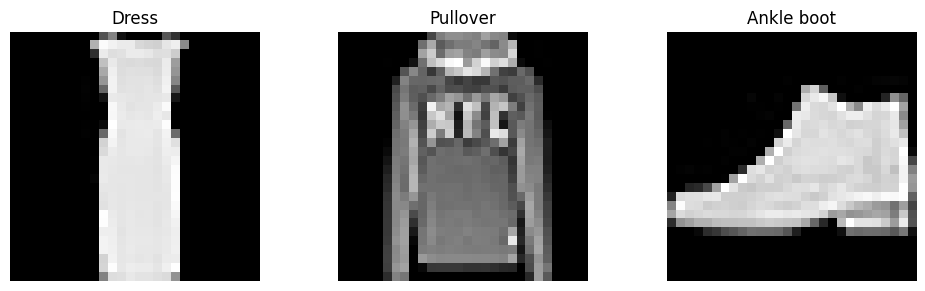

In [ ]:
import random
import matplotlib.pyplot as plt

def show_random_images(dataset, n=3):
    """Visualize n random images from a FashionMNIST dataset with their classes."""

    class_names = dataset.classes
    indices = random.sample(range(len(dataset)), n)

    fig, axes = plt.subplots(1, n, figsize=(10, 3))

    for ax, idx in zip(axes, indices):
        image, label = dataset[idx]

        ax.imshow(image, cmap="gray")
        ax.set_title(class_names[label])
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_random_images(train_dataset)

## 4. Build a Custom Dataset Wrapper

A PyTorch `Dataset` needs two core methods:

- `__len__`: how many samples exist
- `__getitem__`: how to return one `(image, label)` pair

This wrapper keeps the original FashionMNIST data but lets us control the transform pipeline ourselves.


In [ ]:
import torch
from torch.utils.data import Dataset
from torchvision.datasets import FashionMNIST
from torchvision import transforms


class FashionMNISTDataset(Dataset):
    def __init__(
        self,
        root="./data",
        split="train",
        transforms=None,
        download=True
    ):
        super().__init__()

        if split not in ["train", "test"]:
            raise ValueError("split must be either 'train' or 'test'")

        self.split = split
        self.transforms = transforms

        self.dataset = FashionMNIST(
            root=root,
            train=(split == "train"),
            download=download
        )

        self.images = self.dataset.data
        self.labels = self.dataset.targets
        self.classes = self.dataset.classes

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx].item()

        image = transforms.ToPILImage()(image)

        if self.transforms is not None:
            image = self.transforms(image)

        return image, label

## 5. Transforms

Transforms convert raw images into tensors the model can use. Normalization keeps values in a stable range.



In [ ]:
train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = FashionMNISTDataset(
    split="train",
    transforms=train_transforms
)

test_dataset = FashionMNISTDataset(
    split="test",
    transforms=test_transforms
)


In [ ]:
train_dataset[0][0].shape # In torch images must be [c, h, w] not [h, w, c]

torch.Size([1, 28, 28])

## 6. Define the Neural Network

This model is a feed-forward neural network. It flattens each 28 x 28 image into 784 input values, passes them through configurable hidden layers, and outputs 10 class logits.

The `layers` argument must match the number of values in `hidden_units`. For example, `layers=2` and `hidden_units=[32, 32]` creates two hidden linear layers.


In [ ]:
import torch
import torch.nn as nn


class FashionMNISTModelFFNN(nn.Module):
    def __init__(
        self,
        layers: int,
        hidden_units: list[int]
    ):
        super().__init__()

        if layers != len(hidden_units):
            raise ValueError("layers must be equal to len(hidden_units)")

        self.layers = layers
        self.hidden_units = hidden_units

        input_units = 28 * 28
        output_units = 10

        self.flatten_layer = nn.Flatten()
        network_layers = []

        previous_units = input_units

        for units in hidden_units:
            network_layers.append(nn.Linear(previous_units, units))
            network_layers.append(nn.ReLU())
            previous_units = units

        network_layers.append(nn.Linear(previous_units, output_units))

        self.network = nn.Sequential(*network_layers)

    def forward(self, x):
        x = self.flatten_layer(x)
        return self.network(x)

In [ ]:
## DEBUG CELL ##

model = FashionMNISTModelFFNN(
    3, [32, 64, 32]
)
x = torch.rand(1, 28, 28)
print(x.shape)
model(x).shape

torch.Size([1, 28, 28])


torch.Size([1, 10])

## 7. Training Setup

The dataloaders create mini-batches, the loss function measures prediction error, and the optimizer updates model weights. The parameter-count snippet shows how large the current model is, which is useful when comparing smaller and larger architectures.


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import SGD

EPOCHS = 10
BATCH_SIZE = 16
LR = 1e-3  # 0.001
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using: {device}")

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

model = FashionMNISTModelFFNN(
    layers=2,
    hidden_units=[32, 32]
).to(device)

# Source: https://stackoverflow.com/a/49201237
# Posted by Fabio Perez, modified by community. License: CC BY-SA 4.0
pytorch_total_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)
print(f"Trainable parameters: {pytorch_total_params:,}")

loss_fn = nn.CrossEntropyLoss()

optimizer = SGD(
    params=model.parameters(),
    lr=LR
)


Using: cuda
Trainable parameters: 26,506


In [ ]:
images, labels = next(iter(train_dataloader))

print(images.shape)  # torch.Size([16, 1, 28, 28])
print(labels.shape)  # torch.Size([16])

torch.Size([16, 1, 28, 28])
torch.Size([16])


## 8. Train Loop

The train loop uses the standard PyTorch pattern:

1. set the model to training mode with `model.train()`
2. move each batch to the selected device
3. run a forward pass
4. compute loss
5. clear old gradients
6. backpropagate with `loss.backward()`
7. update parameters with `optimizer.step()`
8. track loss and accuracy


In [ ]:
from tqdm.auto import tqdm

for epoch in range(EPOCHS):
    model.train()

    epoch_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    progress_bar = tqdm(
        train_dataloader,
        desc=f"Epoch {epoch + 1}/{EPOCHS}",
        leave=True
    )

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        logits = model(images)
        loss = loss_fn(logits, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Track metrics
        epoch_loss += loss.item()

        predictions = logits.argmax(dim=1)
        correct_predictions += (predictions == labels).sum().item()
        total_predictions += labels.size(0)

        current_loss = epoch_loss / total_predictions * labels.size(0)
        current_accuracy = correct_predictions / total_predictions

        # Update the progress bar information
        progress_bar.set_postfix(
            loss=f"{current_loss:.4f}",
            accuracy=f"{current_accuracy:.2%}"
        )

    average_loss = epoch_loss / len(train_dataloader)
    accuracy = correct_predictions / total_predictions

    print(
        f"Epoch: {epoch + 1:3}/{EPOCHS} | "
        f"Loss: {average_loss:.4f} | "
        f"Accuracy: {accuracy:.2%}"
    )

Epoch 1/10:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch:   1/10 | Loss: 1.5085 | Accuracy: 51.83%


Epoch 2/10:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch:   2/10 | Loss: 0.7293 | Accuracy: 74.68%


Epoch 3/10:   0%|          | 0/3750 [00:00<?, ?it/s]

...

Epoch:   8/10 | Loss: 0.4709 | Accuracy: 83.20%


Epoch 9/10:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch:   9/10 | Loss: 0.4582 | Accuracy: 83.73%


Epoch 10/10:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch:  10/10 | Loss: 0.4480 | Accuracy: 84.06%


# Exercises

Use these tasks to turn the demonstration into practice. Run one experiment at a time and write down the result before changing the next thing.


## Exercise 1: Write the Test Loop

Implement an evaluation loop using `test_dataloader`.

Requirements:

- use `model.eval()`
- wrap the loop in `with torch.inference_mode():`
- move `images` and `labels` to `device`
- compute average test loss
- compute test accuracy
- do not call `optimizer.zero_grad()`, `loss.backward()`, or `optimizer.step()` during testing


In [ ]:
# TODO: Exercise 1 - write the test loop

model.eval()
test_loss = 0.0
correct_predictions = 0
total_predictions = 0

with torch.inference_mode():
    for images, labels in test_dataloader:
        # 1. Move images and labels to device
        # 2. Run the model and compute loss
        # 3. Convert logits to predicted classes
        # 4. Update test_loss, correct_predictions, and total_predictions
        pass

# TODO: Calculate average_test_loss and test_accuracy
# print(f"Test loss: {average_test_loss:.4f} | Test accuracy: {test_accuracy:.2%}")


## Exercise 2: Adjust the Neural Network

Change `layers` and `hidden_units` in the model setup cell, then rerun the parameter-count line.

Try at least three versions:

- a smaller network, for example `[16]`
- the current network, `[32, 32]`
- a larger network, for example `[128, 64, 32]`

For each version, record the number of trainable parameters and the train/test accuracy. The goal is to notice the tradeoff between capacity, speed, and generalization.


In [ ]:
# TODO: Exercise 2 - compare model sizes

experiments = [
    {"layers": 1, "hidden_units": [16]},
    {"layers": 2, "hidden_units": [32, 32]},
    {"layers": 3, "hidden_units": [128, 64, 32]},
]

for config in experiments:
    candidate_model = FashionMNISTModelFFNN(**config)
    trainable_params = sum(
        p.numel() for p in candidate_model.parameters() if p.requires_grad
    )
    print(f"{config}: {trainable_params:,} trainable parameters")


## Exercise 3: Experiment with Data Augmentation

Research what data augmentation means in computer vision, then test how it changes training.

Try adding or removing transforms such as:

- `transforms.RandomRotation(degrees=10)`
- `transforms.RandomHorizontalFlip(p=0.25)`
- `transforms.RandomAffine(degrees=0, translate=(0.1, 0.1))`

Questions to answer:

- Which augmentations make sense for clothing images?
- Which augmentations could change the label or make the image unrealistic?
- Does augmentation improve test accuracy, reduce overfitting, or slow training?


In [ ]:
# TODO: Exercise 3 - create your own augmentation pipeline

my_train_transforms = transforms.Compose([
    # Add your experiments here.
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

my_train_dataset = FashionMNISTDataset(
    split="train",
    transforms=my_train_transforms
)

sample_image, sample_label = my_train_dataset[0]
print(sample_image.shape, my_train_dataset.classes[sample_label])


In [ ]:
#@title Submit to leaderboard
SENDER_NAME = "your-name-here" #@param {type:"string"}

import requests, pandas as pd
from pathlib import Path
from IPython.display import display

p = Path("submission.pt")
if not p.exists(): raise FileNotFoundError(f"Missing {p.resolve()}")

u = requests.get("https://tues-ai.github.io/PyTorch-Intro/server-url/current.txt", timeout=10).text.strip()
if not u: raise RuntimeError("Leaderboard server is sleeping.")

with p.open("rb") as f:
    r = requests.post(
        f"{u.rstrip('/')}/api/submit",
        data={"name": SENDER_NAME},
        files={"model_file": (p.name, f, "application/octet-stream")},
        timeout=300,
    )

data = r.json()
if not r.ok: raise RuntimeError(data.get("error", r.text))

s = data["score"]
print(f"{s['name']} | acc={s['accuracy']*100:.2f}% | {s['correct']}/{s['total']} | loss={s['loss']:.4f}")

df = pd.DataFrame(data["leaderboard"])
df["accuracy"] *= 100
display(df[["rank", "name", "accuracy", "loss", "correct", "total", "seconds"]])
